### Platesolving Manual
Written by Ashley Ashiku, 02/12/26, PULSE-A OGS Telescope Engineer

Here, I will walk through the platesolving process for a star camera image. First, we need to select the image we're platesolving.

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
from twirl import find_peaks
import numpy as np
import pandas as pd
from astroquery.astrometry_net import AstrometryNet
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from twirl.geometry import sparsify
from photutils.aperture import CircularAperture
from twirl import gaia_radecs
from twirl.geometry import sparsify
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.coordinates import Angle

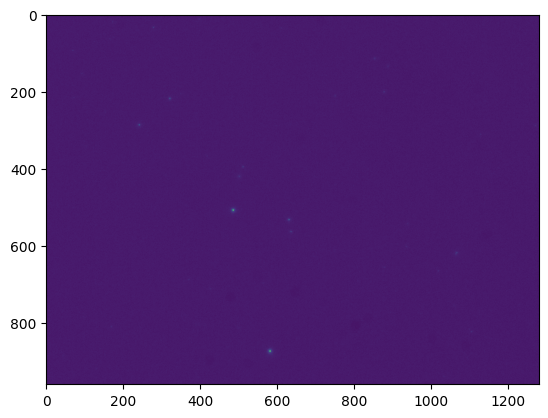

In [57]:
image = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/FIRSTstar.fits')
header = image[0].header        # image header
data = image[0].data            # image data (counts per pixel)

plt.imshow(data)   # making a picture

Great! We pull out the image data, you can see it above. Also, note that there's no information stored in the header either: we're blind platesolving!

In [5]:
print(header)

SIMPLE  =                    T                                                  BITPIX  =                    8                                                  NAXIS   =                    2                                                  NAXIS1  =                 1280                                                  NAXIS2  =                  960                                                  BSCALE  =         1.000000E+00                                                  BZERO   =         0.000000E+00                                                  DATAMAX =         2.550000E+02                                                  DATAMIN =         0.000000E+00                                                  HISTORY https://legacy.imagemagick.org                                          END                                                                                                                                                                                                     

Next, we're going to pull out a table of the brightest sources (presumably stars). We'll do the brightest 10 and store their matching fluxes in a table. We're also going to sort them by dimmest-to-brightest. Sometimes, we do 20 stars. This time, I'm doing only 10 because we can't see too much.

In [77]:
xy = find_peaks(data)[0:10]
x = np.array(xy[:,0])
y = np.array(xy[:,1])

rX = []
rY = []
for i in range(len(xy)):
    rX.append(int(np.round(x[i])))
    rY.append(int(np.round(y[i])))

flux_val = data[rY, rX]
sources = np.array([x, y, flux_val])
source_list = pd.DataFrame(sources.T, columns = ['x', 'y', 'flux_val'])
source_list.sort_values('flux_val', ascending = True) # sorting


,x,y,flux_val
5,1064.723954,620.018534,45.0
6,501.230378,420.982205,57.0
9,853.229364,114.777402,60.0
7,635.395929,563.931450,66.0
8,510.803059,396.057999,88.0
4,321.474120,218.703157,102.0
2,630.333840,532.918061,136.0
3,241.665905,287.232558,141.0
0,581.266394,874.773620,219.0
1,485.865203,508.481401,255.0


Great! Now, we pass this table towards Astrometry.Net, which will do the platesolving for us.

In [78]:
ast = AstrometryNet()
ast.api_key = 'cgiokceqsveywcin'

wcs_header = ast.solve_from_source_list(source_list['x'], source_list['y'], width, height, solve_timeout=120)

Solving.............

In [80]:
print(WCS(wcs_header))

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 86.6588839481 -4.01762013396 
CRPIX : 629.218751137 594.008237309 
CD1_1 CD1_2  : -1.39453077407e-05 0.00173606753811 
CD2_1 CD2_2  : 0.00173510303354 2.03861271824e-05 
NAXIS : 0  0


Awesome! This platesolving was successful. The result is a conversion between camera pixels and RA/dec. We can apply this conversion to any pixel to get the corresponding RA/dec, or vice versa. 

What I'm going to do next is verify the legitimacy of this platesolving. We're going to first list the height and width of our camera's images. Make sure you use the correct camera, since the tracking and star cameras have different sizes. Then, we're going to find all the stars in the region from the Gaia survey.

The FOV does the pixel scaling stuff (determining roughly how many pixels translates to a certain distance on sky). The center is the center pixel coordinates translated into celestial coordinates. Then, we pull out all gaia star RA/decs in a circular radius around the center RA/dec (you can adjust the radius to be bigger/smaller by changing the number multiplying fov), weed out the stars within 0.05 degrees (you can change this number too depending on image), and convert their celestial coordinates into pixel coordinates.

In [162]:
width = 1280        # star camera image width, pixels
height = 960       # star camera image height, pixels

#width = 2048        # tracking camera image width, pixels
#height = 2064       # tracking camera image height, pixels

centerP = np.array([width, height])
centerP = centerP/2

fov = (data.shape * proj_plane_pixel_scales(WCS(wcs_header)))[0]
center = WCS(wcs_header).pixel_to_world(centerP[0], centerP[1])
all_radecs = gaia_radecs(center, 1.2 * fov)             # adjust radius here by number multipled by fov
all_radecs = sparsify(all_radecs, 0.03)                 # adjust allowed spacing between gaia stars 
radecs_xy = np.array(WCS(wcs_header).world_to_pixel_values(all_radecs))

Find the center of the image and its corresponding RA and dec, and convert RA into hr/min/sec from degrees:

In [163]:
print(center)

ra, dec = 86.46153224, -3.99933477

px, py = WCS(wcs_header).wcs_world2pix(ra, dec, 1)
print(px, py)

c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

ra_hms = c.ra.hms
print(f"RA in HMS: {ra_hms.h}h {ra_hms.m}m {ra_hms.s}s")

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (86.46167696, -3.99934745)>
641.0748679095385 480.7024064830131
RA in HMS: 5.0h 45.0m 50.767737600003926s


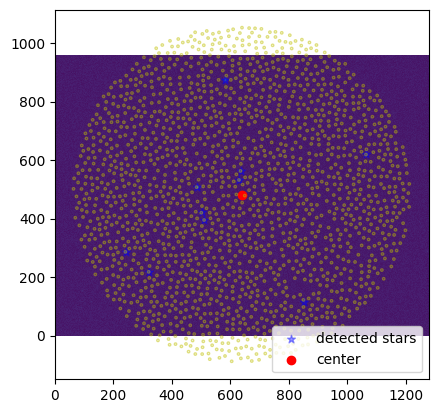

In [164]:
plt.imshow(data, origin='lower', interpolation='nearest')
plt.scatter(x, y, marker = '*', alpha = 0.4, color = 'blue', label = 'detected stars')
plt.scatter(641.0748679095385, 480.7024064830131, color = 'red', label = 'center')
_ = CircularAperture(radecs_xy, 4).plot(color="y", alpha=0.5)


#plt.scatter(638.0265939885123, 477.16456732194, marker = 'x', color = 'green', label = 'hd 294344')
#plt.scatter(470.34667453763024, 654.1623643453322, marker = 'x', color = 'green', label = 'hd 294343')

plt.legend()

In [168]:
xxx = 582.818
yyy = 874.228 

ccc = WCS(wcs_header).pixel_to_world(xxx, yyy)
print(ccc)

ra_hms = ccc.ra.hms
print(f"RA in HMS: {ra_hms.h}h {ra_hms.m}m {ra_hms.s}s")


<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (87.1463244, -4.08975043)>
RA in HMS: 5.0h 48.0m 35.117857043457406s


In [104]:
print(center)

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (86.46167696, -3.99934745)>


In [106]:
# Define RA (deg) and Dec (deg)
ra_deg = 86.46167696
dec_deg = -3.99934745

# Create SkyCoord object
c = SkyCoord(ra=ra_deg*u.degree, dec=dec_deg*u.degree, frame='icrs')

# Convert RA to hours
ra_hour = c.ra.hour
print(f"RA in hours: {ra_hour}") # 18.2953...

# Convert to Hours:Minutes:Seconds string
ra_hms = c.ra.hms
print(f"RA in HMS: {ra_hms.h}h {ra_hms.m}m {ra_hms.s}s")

angle = Angle(dec_deg, u.degree)


RA in hours: 5.764111797333335
RA in HMS: 5.0h 45.0m 50.80247040000643s


In [147]:
# convert to degrees

c = SkyCoord('05 45 46.4 -03 58 36.6', unit=(u.hourangle, u.deg))
print(c)

raIn = 86.44333333
decIn = -3.97683333

px1, px2 = WCS(wcs_header).wcs_world2pix(raIn, decIn, 1)
print(px1, px2)

<SkyCoord (ICRS): (ra, dec) in deg
    (86.44333333, -3.97683333)>
654.1623643453322 470.34667453763024


Nice! Let's try this again, with calibration images. First, pull out the new images we're using.

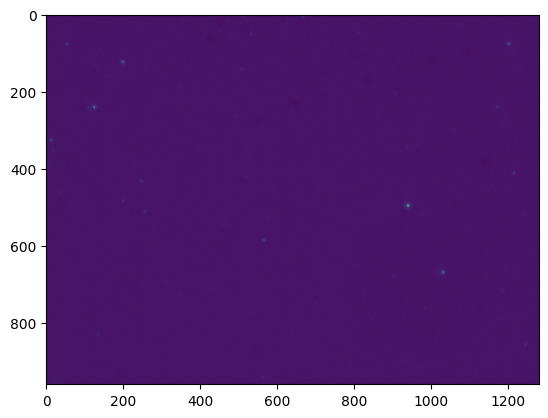

In [8]:
dark_F = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/starcamera/DARKFRAME.fits')
bias_F = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/starcamera/BIASFRAME.fits')
flat_F = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/starcamera/FLATFRAME3.fits')

image_F = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/sunday/CALBRATE0.fits')

darkD = dark_F[0].data
biasD = bias_F[0].data
flatD = flat_F[0].data
imageD = image_F[0].data

plt.imshow(imageD)

In [11]:
xy = find_peaks(imageD)[0:10]
x = np.array(xy[:,0])
y = np.array(xy[:,1])

rX = []
rY = []
for i in range(len(xy)):
    rX.append(int(np.round(x[i])))
    rY.append(int(np.round(y[i])))

flux_val = imageD[rY, rX]
sources = np.array([x, y, flux_val])
source_list = pd.DataFrame(sources.T, columns = ['x', 'y', 'flux_val'])
source_list.sort_values('flux_val', ascending = True) # sorting


,x,y,flux_val
8,54.287578,77.599426,48.0
9,1171.479863,240.110562,48.0
6,564.421530,586.358521,52.0
1,122.021499,241.420626,58.0
7,1213.938549,410.773302,79.0
5,13.808541,326.488182,87.0
4,1201.169801,76.748851,103.0
3,199.359418,123.658781,107.0
2,1029.985675,669.281444,130.0
0,938.870145,495.709119,233.0


In [12]:
ast = AstrometryNet()
ast.api_key = 'cgiokceqsveywcin'

width = 1280        # star camera image width, pixels
height = 960       # star camera image height, pixels

#width = 2048        # tracking camera image width, pixels
#height = 2064       # tracking camera image height, pixels



wcs_header = ast.solve_from_source_list(source_list['x'], source_list['y'], width, height, solve_timeout=120)

Solving.........

In [13]:
print(WCS(wcs_header))

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 80.9468411046 5.33238491353 
CRPIX : 933.61178769 457.024483715 
CD1_1 CD1_2  : -0.000467092169897 -0.00166625026855 
CD2_1 CD2_2  : 0.00166861973005 -0.000463166818667 
NAXIS : 0  0


In [19]:
width = 1280        # star camera image width, pixels
height = 960       # star camera image height, pixels

#width = 2048        # tracking camera image width, pixels
#height = 2064       # tracking camera image height, pixels

centerP = np.array([width, height])
centerP = centerP/2

fov = (imageD.shape * proj_plane_pixel_scales(WCS(wcs_header)))[0]
center = WCS(wcs_header).pixel_to_world(centerP[0], centerP[1])
all_radecs = gaia_radecs(center, 1.8 * fov)             # adjust radius here by number multipled by fov
all_radecs = sparsify(all_radecs, 0.03)                 # adjust allowed spacing between gaia stars 
radecs_xy = np.array(WCS(wcs_header).world_to_pixel_values(all_radecs))

In [20]:
print(center)

ra, dec = 86.46153224, -3.99933477

px, py = WCS(wcs_header).wcs_world2pix(ra, dec, 1)
print(px, py)

c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

ra_hms = c.ra.hms
print(f"RA in HMS: {ra_hms.h}h {ra_hms.m}m {ra_hms.s}s")

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (81.04404477, 4.83291685)>
-5176.45704143347 -1186.5022437789648
RA in HMS: 5.0h 45.0m 50.767737600003926s


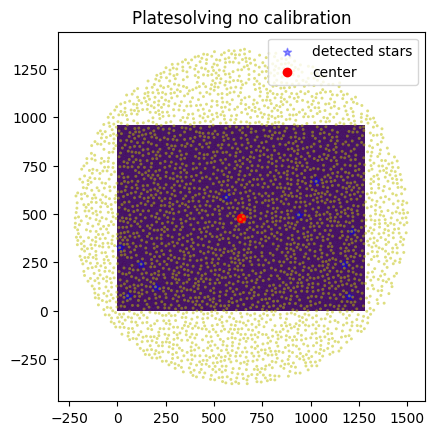

In [21]:
plt.imshow(imageD, origin='lower', interpolation='nearest')
plt.scatter(x, y, marker = '*', alpha = 0.4, color = 'blue', label = 'detected stars')
plt.scatter(641.0748679095385, 480.7024064830131, color = 'red', label = 'center')
_ = CircularAperture(radecs_xy, 4).plot(color="y", alpha=0.5)
plt.title("Platesolving no calibration")

#plt.scatter(638.0265939885123, 477.16456732194, marker = 'x', color = 'green', label = 'hd 294344')
#plt.scatter(470.34667453763024, 654.1623643453322, marker = 'x', color = 'green', label = 'hd 294343')

plt.legend()

Let's try and calibrate first image.

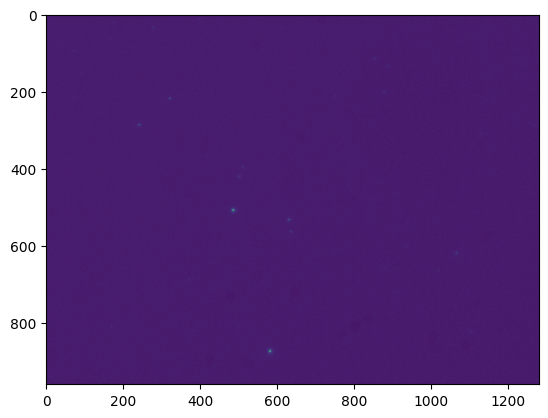

In [24]:
image = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/FIRSTstar.fits')
data = image[0].data            # image data (counts per pixel)

calibrateD = data - biasD - (darkD - biasD)

plt.imshow(calibrateD)   # making a picture

In [25]:
xy = find_peaks(calibrateD)[0:10]
x = np.array(xy[:,0])
y = np.array(xy[:,1])

rX = []
rY = []
for i in range(len(xy)):
    rX.append(int(np.round(x[i])))
    rY.append(int(np.round(y[i])))

flux_val = calibrateD[rY, rX]
sources = np.array([x, y, flux_val])
source_list = pd.DataFrame(sources.T, columns = ['x', 'y', 'flux_val'])
source_list.sort_values('flux_val', ascending = True) # sorting


,x,y,flux_val
5,1064.938413,620.140545,44.0
7,501.581090,420.269881,45.0
9,279.100410,33.705943,58.0
6,635.259599,564.007450,65.0
8,511.328922,396.215501,88.0
4,321.107009,218.576658,101.0
2,241.146742,287.315777,126.0
3,629.898909,532.847034,135.0
0,581.199156,874.630333,218.0
1,485.547987,508.450743,255.0


In [27]:
ast = AstrometryNet()
ast.api_key = 'cgiokceqsveywcin'

wcs_header = ast.solve_from_source_list(source_list['x'], source_list['y'], width, height, solve_timeout=120)

Solving.............

In [28]:
print(WCS(wcs_header))

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 86.6589108358 -4.01682007581 
CRPIX : 629.094770344 594.028884703 
CD1_1 CD1_2  : -1.25955241293e-05 0.00173728143873 
CD2_1 CD2_2  : 0.00173716719508 2.87566449895e-05 
NAXIS : 0  0


In [29]:
width = 1280        # star camera image width, pixels
height = 960       # star camera image height, pixels

#width = 2048        # tracking camera image width, pixels
#height = 2064       # tracking camera image height, pixels

centerP = np.array([width, height])
centerP = centerP/2

fov = (calibrateD.shape * proj_plane_pixel_scales(WCS(wcs_header)))[0]
center = WCS(wcs_header).pixel_to_world(centerP[0], centerP[1])
all_radecs = gaia_radecs(center, 1.2 * fov)             # adjust radius here by number multipled by fov
all_radecs = sparsify(all_radecs, 0.03)                 # adjust allowed spacing between gaia stars 
radecs_xy = np.array(WCS(wcs_header).world_to_pixel_values(all_radecs))

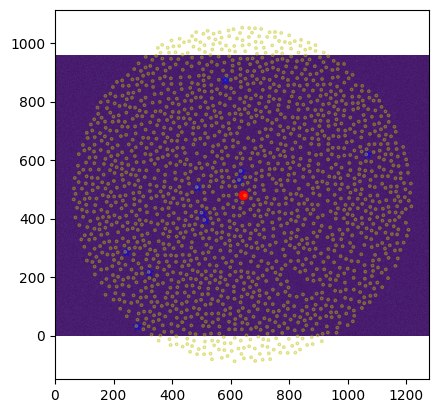

In [31]:
plt.imshow(calibrateD, origin='lower', interpolation='nearest')
plt.scatter(x, y, marker = '*', alpha = 0.4, color = 'blue', label = 'detected stars')
plt.scatter(641.0748679095385, 480.7024064830131, color = 'red', label = 'center')
_ = CircularAperture(radecs_xy, 4).plot(color="y", alpha=0.5)


#plt.scatter(638.0265939885123, 477.16456732194, marker = 'x', color = 'green', label = 'hd 294344')
#plt.scatter(470.34667453763024, 654.1623643453322, marker = 'x', color = 'green', label = 'hd 294343')

#plt.legend()

### Random after this

In [26]:
all_radecs = gaia_radecs(center, 1.2 * fov)
print(len(all_radecs))

# we only keep stars 0.01 degree apart from each other
all_radecs = sparsify(all_radecs, 0.01)
print(len(all_radecs))

10000


KeyboardInterrupt: 

In [19]:
from twirl import compute_wcs
from photutils.aperture import CircularAperture

In [17]:
wcs = compute_wcs(xy, all_radecs[0:30], tolerance=10)

6
Match took 276328.802 us


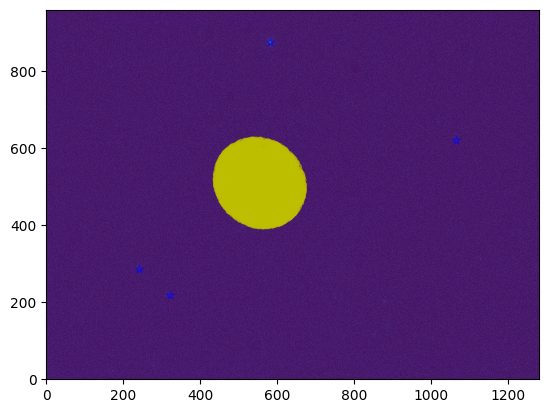

In [29]:
plt.imshow(data, origin='lower', interpolation='nearest')
plt.scatter(x, y, marker = '*', alpha = 0.4, color = 'blue')
#plt.imshow(data, vmin=np.median(data), vmax=3 * np.median(data), cmap="Greys_r")
_ = CircularAperture(radecs_xy, 5).plot(color="y", alpha=0.5)

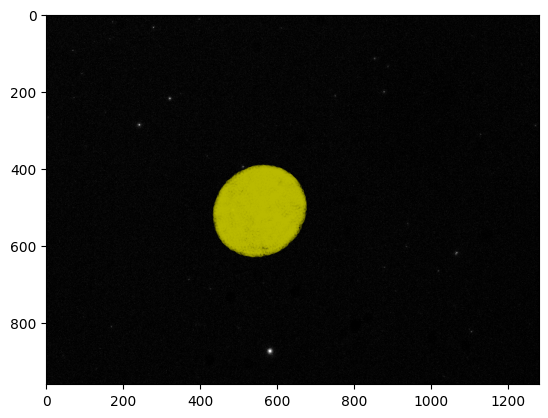

In [21]:
radecs_xy = np.array(wcs.world_to_pixel_values(all_radecs))
plt.imshow(data, vmin=np.median(data), vmax=3 * np.median(data), cmap="Greys_r")
_ = CircularAperture(radecs_xy, 5).plot(color="y", alpha=0.2)